In [1]:
import gzip
import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm

from download import fetch_hydrocron, download_mrms
from plot import plot_heatmap
from utilities import filter_bits

# Preferences
use_cache = True

# Set up data path
data_dir = pathlib.Path().cwd().parent / 'data'
data_dir.mkdir(exist_ok=True, parents=True)
precip_path = data_dir / 'MRMS_{var_name}.csv'
swot_path = data_dir / 'swot_timeseries_new.csv'

# Satellite tracks for test site on Willamette River
passes = [39, 274, 345]
# Site bounding box
bounds = (-123.4, 44, -123, 45)
bbox = shapely.geometry.box(*bounds)
start_time = '2023-01-01T00:00:00Z'
end_time = '2026-01-01T00:00:00Z'

# Set up data path
data_dir = pathlib.Path().cwd().parent / 'data'
data_dir.mkdir(exist_ok=True, parents=True)
precip_path = str(data_dir / 'tst_MRMS_{var_name}.csv')
swot_path = data_dir / 'swot_timeseries_new_vD.csv'
# swot_path = data_dir / 'swot_timeseries_new.csv'

In [2]:
precip_path

'c:\\Users\\matth\\repos\\swot-precip-validation\\data\\tst_MRMS_{var_name}.csv'

In [3]:
swot_ts_df = (
    pd.read_csv(
        swot_path, 
        na_values=['no_data'],
        index_col=['node_id', 'time_str'],
        parse_dates=True)
    .rename_axis(index={"time_str": "time"})
)
# Remove NA rows
swot_ts_df = swot_ts_df[swot_ts_df.index.get_level_values("time").notna()]

# Filter data
swot_filter_df = swot_ts_df.copy()
# Not ice
swot_filter_df = swot_filter_df[swot_filter_df.ice_clim_f==0]
# Not bad xover
swot_filter_df = swot_filter_df[swot_filter_df.xovr_cal_q<2]
# Not bad xover
# swot_filter_df = swot_filter_df[swot_filter_df.node_q<3]
# Not far or near swath
swot_filter_df = swot_filter_df[swot_filter_df.node_q_b.apply(filter_bits, args=[[13,14,19,23,24]])]
# swot_filter_df = swot_filter_df[swot_filter_df.node_q_b.apply(filter_bits)]

swot_filter_df

C:\Users\matth\AppData\Local\Temp\ipykernel_25184\2750314503.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv(


wse       width  area_total  \
node_id        time                                                           
78220000130171 2023-04-02 08:16:23+00:00   33.40192  163.621311     33032.5   
               2023-04-03 08:07:01+00:00   34.17190  217.799270     43970.2   
               2023-04-06 07:38:54+00:00   33.90466  227.684702     45965.9   
               2023-04-09 07:10:49+00:00   34.38848  263.706610     53238.2   
               2023-04-10 07:01:27+00:00   34.31745  163.048361     32916.9   
...                                             ...         ...         ...   
78220000390651 2025-12-14 22:20:43+00:00  132.45745  165.928528     30459.9   
               2025-12-23 07:24:54+00:00  132.99160  179.606198     32970.8   
               2026-01-04 19:05:50+00:00  132.61207  193.581687     35536.3   
               2026-01-13 04:09:58+00:00  132.53452  144.109807     26454.6   
               2026-01-25 15:50:54+00:00  132.29128  195.593952     35905.7   

                                          node_q_b  ice_clim_f  xovr_cal_q  \
node_id        time                                                          
78220000130171 2023-04-02 08:16:23+00:00         0           0           0   
               2023-04-03 08:07:01+00:00         0           0           0   
               2023-04-06 07:38:54+00:00         4           0           0   
               2023-04-09 07:10:49+00:00         2           0           0   
               2023-04-10 07:01:27+00:00         2           0           0   
...                                            ...         ...         ...   
78220000390651 2025-12-14 22:20:43+00:00         2           0           0   
               2025-12-23 07:24:54+00:00        14           0           0   
               2026-01-04 19:05:50+00:00         2           0           0   
               2026-01-13 04:09:58+00:00        14           0           0   
               2026-01-25 15:50:54+00:00         2           0           0   

                                          p_dam_id  dark_frac  n_good_pix  \
node_id        time                                                         
78220000130171 2023-04-02 08:16:23+00:00         0   0.000000          91   
               2023-04-03 08:07:01+00:00         0   0.000000         132   
               2023-04-06 07:38:54+00:00         0   0.006462         144   
               2023-04-09 07:10:49+00:00         0   0.000000         148   
               2023-04-10 07:01:27+00:00         0   0.000000         126   
...                                            ...        ...         ...   
78220000390651 2025-12-14 22:20:43+00:00         0   0.120194          36   
               2025-12-23 07:24:54+00:00         0   0.000000          29   
               2026-01-04 19:05:50+00:00         0   0.253088          35   
               2026-01-13 04:09:58+00:00         0   0.000000          31   
               2026-01-25 15:50:54+00:00         0   0.123913          34   

                                                lat  ...  rdr_sig0_units  \
node_id        time                                  ...                   
78220000130171 2023-04-02 08:16:23+00:00  44.989367  ...               1   
               2023-04-03 08:07:01+00:00  44.989018  ...               1   
               2023-04-06 07:38:54+00:00  44.989060  ...               1   
               2023-04-09 07:10:49+00:00  44.988798  ...               1   
               2023-04-10 07:01:27+00:00  44.989085  ...               1   
...                                             ...  ...             ...   
78220000390651 2025-12-14 22:20:43+00:00  44.079055  ...               1   
               2025-12-23 07:24:54+00:00  44.079038  ...               1   
               2026-01-04 19:05:50+00:00  44.079028  ...               1   
               2026-01-13 04:09:58+00:00  44.079045  ...               1   
               2026-01-25 15:50:54+00:00  44.079012  ...               1   

              

In [4]:
cols = np.sort(swot_filter_df.columns.values)
print(cols)

['area_total' 'area_total_units' 'dark_frac' 'dark_frac_units'
 'dry_trop_c' 'dry_trop_c_units' 'ice_clim_f' 'iono_c' 'iono_c_units'
 'lat' 'lat_u' 'lat_u_units' 'lat_units' 'lon' 'lon_u' 'lon_u_units'
 'lon_units' 'n_good_pix' 'n_good_pix_units' 'node_q_b' 'p_dam_id'
 'p_dam_id_units' 'p_wid_var' 'p_wid_var_units' 'p_width' 'p_width_units'
 'p_wse' 'p_wse_units' 'p_wse_var' 'p_wse_var_units' 'rdr_pol' 'rdr_sig0'
 'rdr_sig0_u' 'rdr_sig0_u_units' 'rdr_sig0_units' 'wet_trop_c'
 'wet_trop_c_units' 'width' 'width_units' 'wse' 'wse_units' 'xovr_cal_c'
 'xovr_cal_c_units' 'xovr_cal_q']


In [5]:
# precip_flag_path = "/Users/masa6503/Library/CloudStorage/OneDrive-UCB-O365/Documents/SWOT/swot-precip-validation/data/MRMS_PrecipFlag_00.00.csv"
precip_flag_path = precip_path.format(var_name="PrecipFlag_00.00")
precip_flag_df = pd.read_csv(
    precip_flag_path, 
    # index_col=['node_id', 'time'],
    parse_dates=True
)

precip_flag_df.rename(columns={'PrecipFlag_00.00': 'precip_flag'}, inplace=True)
precip_flag_df['time'] = pd.to_datetime(precip_flag_df['time'])
precip_flag_df.set_index(['node_id', 'time'], inplace=True)
precip_flag_df['precip_flag_binary'] = precip_flag_df.precip_flag.isin([1, 6, 7, 10, 91, 96])


precip_rate_path =  precip_path.format(var_name="PrecipRate_00.00")
precip_rate_df = pd.read_csv(
    precip_rate_path, 
    # index_col=['node_id', 'time'],
    parse_dates=True
)

precip_rate_df.rename(columns={'PrecipRate_00.00': 'precip_rate'}, inplace=True)
precip_rate_df['time'] = pd.to_datetime(precip_rate_df['time'])
precip_rate_df.set_index(['node_id', 'time'], inplace=True)


In [6]:
precip_quality_path =  precip_path.format(var_name="RadarAccumulationQualityIndex_01H_00.00")
precip_quality_df = pd.read_csv(
    precip_quality_path, 
    # index_col=['node_id', 'time'],
    parse_dates=True
)

precip_quality_df.rename(columns={'RadarAccumulationQualityIndex_01H_00.00': 'radar_quality'}, inplace=True)
precip_quality_df['time'] = pd.to_datetime(precip_quality_df['time'])
precip_quality_df.set_index(['node_id', 'time'], inplace=True)


In [7]:
flag_mapping = {
    -3: 'No Coverage',
    0: 'No Precip',
    1: 'Warm Stratiform',
    3: 'Snow',
    6: 'Convective Rain',
    7: 'Rain Mixed Hail',
    10: 'Cold Stratiform ',
    91: 'Tropical/stratiform',
    96: 'Tropical/convective'
}

swot_precip_rate_flag_df = (
    swot_filter_df
    .merge(
        precip_rate_df,
        on=['node_id', 'time']
        )
    .merge(
        precip_flag_df,
        on=['node_id', 'time']
    )
    .merge(
        precip_quality_df,
        on=['node_id', 'time']
    )
    .query(
        "wse>=0 & radar_quality>0.3"
    )
    .assign(precip_type_labeled = lambda df: df['precip_flag'].map(flag_mapping)).fillna("Unknown")
)

<Axes: xlabel='precip_type_labeled', ylabel='dark_frac'>

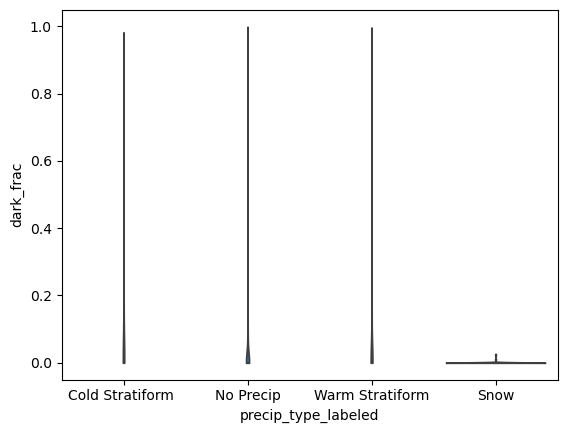

In [8]:
sns.violinplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='dark_frac', log_scale=False,
    inner='quartile',
    cut=0
)

<Axes: xlabel='precip_type_labeled', ylabel='rdr_sig0'>

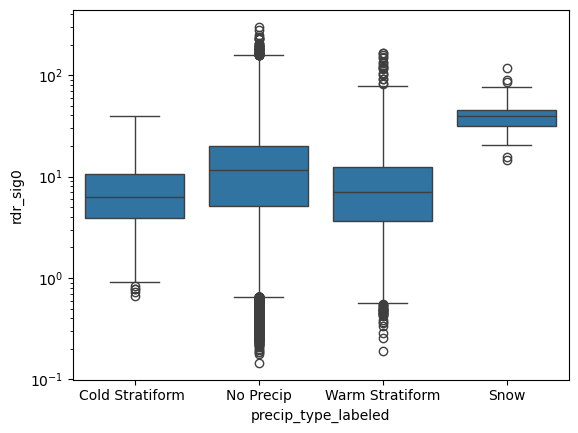

In [9]:
sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='rdr_sig0', log_scale=True
)

In [10]:
n_precip_cats = 9
swot_precip_rate_flag_df['precip_bin_mm_hr'] = pd.cut(swot_precip_rate_flag_df.precip_rate, [-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13], labels = ['0','0-1','1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-9','9-10', '10-11','11-12','12-13'])

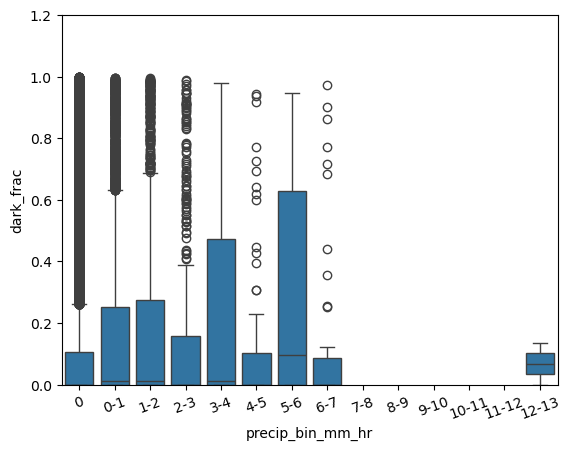

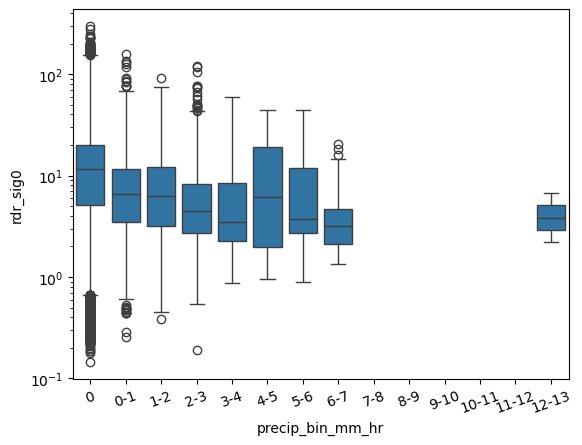

In [11]:
sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_bin_mm_hr', y='dark_frac', log_scale=False
)
plt.ylim(0,1.2)
# Tilt the labels 45 degrees
plt.xticks(rotation=20)
plt.show()

sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_bin_mm_hr', y='rdr_sig0', log_scale=True
)
# plt.ylim(0,1.2)
# Tilt the labels 45 degrees
plt.xticks(rotation=20)
plt.show()

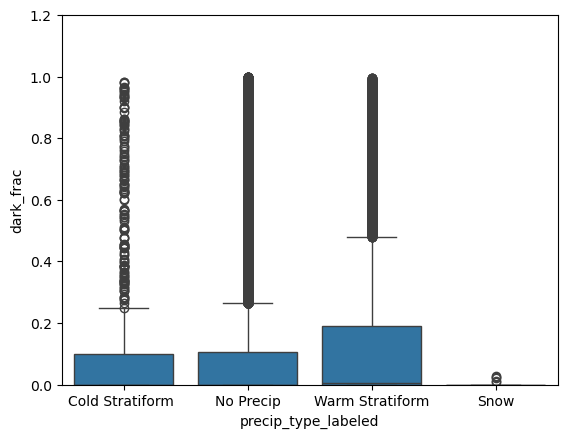

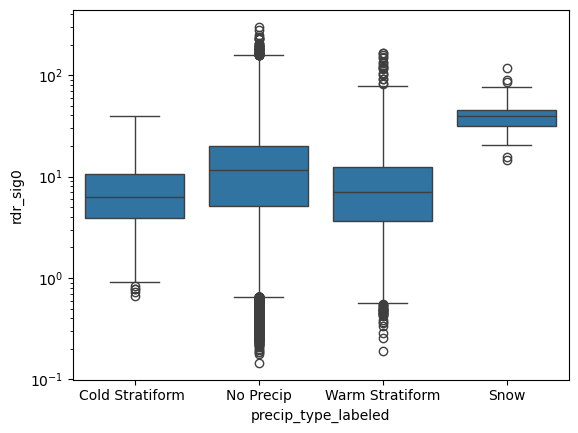

In [12]:
sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='dark_frac', log_scale=False
)
plt.ylim(0,1.2)
# Tilt the labels 45 degrees
# plt.xticks(rotation=20)
plt.show()

sns.boxplot(
    data=swot_precip_rate_flag_df,
    x='precip_type_labeled', y='rdr_sig0', log_scale=True
)
# plt.ylim(0,1.2)
# Tilt the labels 45 degrees
# plt.xticks(rotation=20)
plt.show()

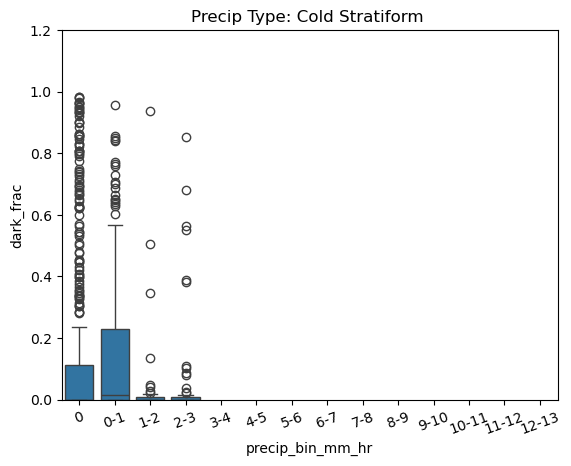

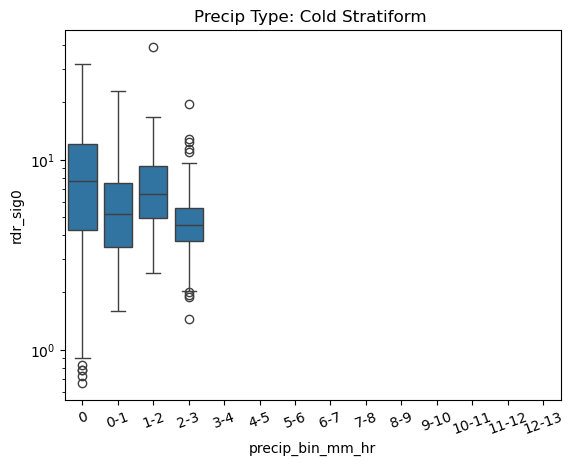

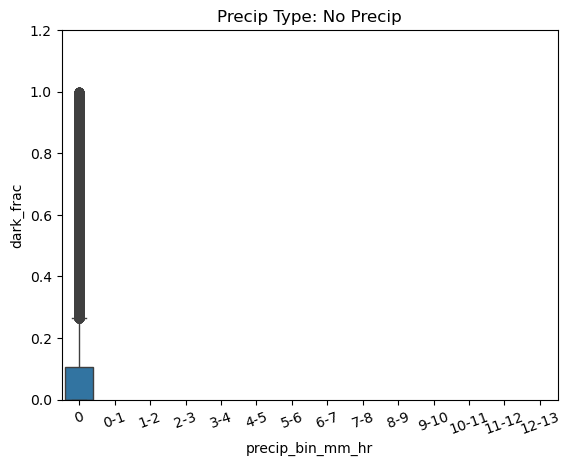

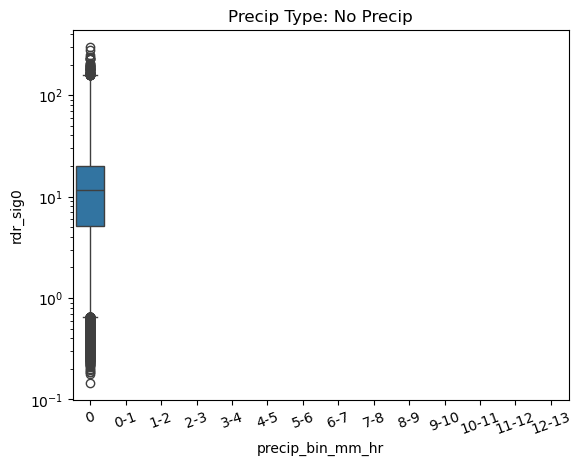

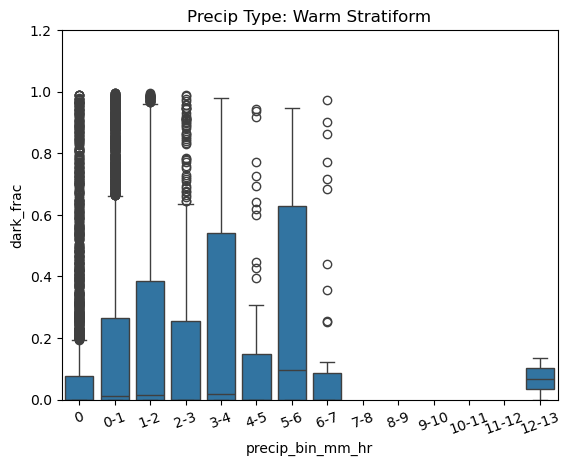

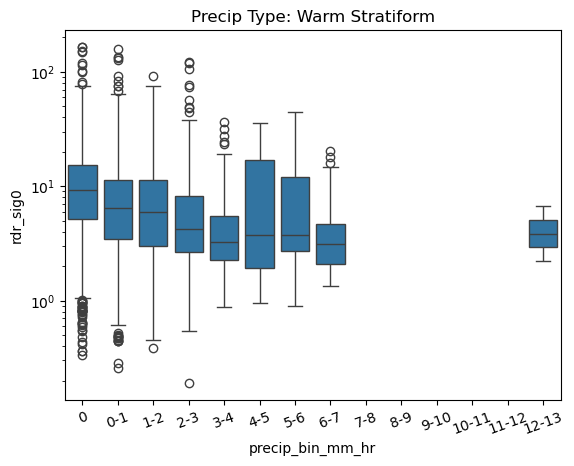

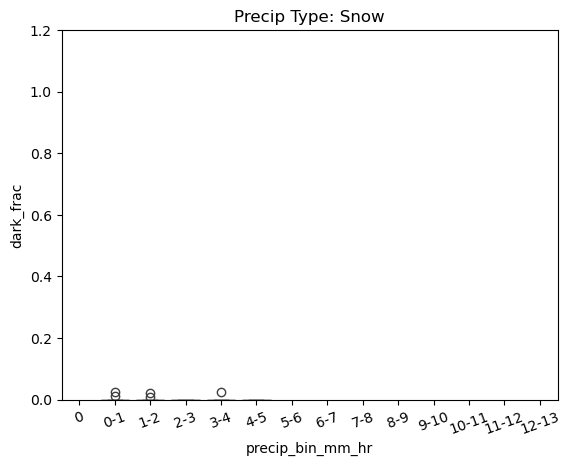

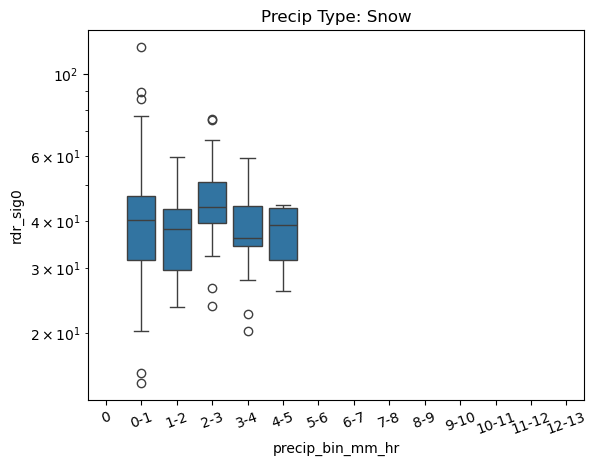

In [13]:
for precip_type in swot_precip_rate_flag_df['precip_type_labeled'].unique():
    subset = swot_precip_rate_flag_df[swot_precip_rate_flag_df['precip_type_labeled'] == precip_type]
    sns.boxplot(
        data=subset,
        x='precip_bin_mm_hr', y='dark_frac', log_scale=False
    )
    plt.ylim(0,1.2)
    # Tilt the labels 45 degrees
    plt.xticks(rotation=20)
    plt.title(f'Precip Type: {precip_type}')
    plt.show()

    sns.boxplot(
        data=subset,
        x='precip_bin_mm_hr', y='rdr_sig0', log_scale=True
    )
    # plt.ylim(0,1.2)
    # Tilt the labels 45 degrees
    plt.xticks(rotation=20)
    plt.title(f'Precip Type: {precip_type}')
    plt.show()

In [14]:
import dataretrieval.waterdata as waterdata

In [ ]:
pcodes,metadata = waterdata.get_reference_table("parameter-codes")
# display(pcodes.head())

streamflow_pcodes = pcodes[pcodes['parameter_name'].str.contains('gauge|height', case=False, na=False)]
display(streamflow_pcodes[['parameter_code', 'parameter_name', 'parameter_description']])

,parameter_code,parameter_name,parameter_description
47,00065,Gage height,"Gage height, feet"
1700,30207,GageHeightAboveDatum,"Gage height, above datum, meters"
3204,45591,"Gate opening, height","Gate opening, height, meters"
3205,45592,"Gate opening, height","Gate opening, height, feet"
13747,70233,Significant wave height,"Significant wave height, feet"
13748,70234,Maximum wave height,"Wave height, maximum, feet"
14001,72172,"Wave height, Fourier","Wave height, Fourier transformation, feet"
14111,72284,Mean wave height,"Wave height, mean, meters"
14115,72288,Maximum wave height,"Wave height, maximum, meters"
18709,99065,Gage height,"Gage height, above datum, meters"


In [27]:
pcodes,metadata = waterdata.get_reference_table("site-type")
display(pcodes.head(100))

# streamflow_pcodes = pcodes[pcodes['parameter_name'].str.contains('gauge|height', case=False, na=False)]
# display(streamflow_pcodes[['parameter_code', 'parameter_name', 'parameter_description']])

ValueError: Invalid code service: 'site-type'. Valid options are: ('agency-codes', 'altitude-datums', 'aquifer-codes', 'aquifer-types', 'coordinate-accuracy-codes', 'coordinate-datum-codes', 'coordinate-method-codes', 'counties', 'hydrologic-unit-codes', 'medium-codes', 'national-aquifer-codes', 'parameter-codes', 'reliability-codes', 'site-types', 'states', 'statistic-codes', 'topographic-codes', 'time-zone-codes').

In [29]:
# gage_id = '14166000'
gage_id = "14174000"
loc_id = f'USGS-{gage_id}'
parameter_codes = ['00065']
statistic_id = '00011'
timeseries = "2023-04-01T00:00:00Z/2026-03-30T12:31:12Z"
elevation_data = waterdata.get_continuous(
    monitoring_location_id=loc_id,
    parameter_code=parameter_codes,
    time=timeseries,
    statistic_id=statistic_id
    )

# gage_id = "14174000"
# loc_id = f'USGS-{gage_id}'
location_info = waterdata.get_monitoring_locations(
    monitoring_location_id=loc_id,
    properties=['monitoring_location_name', 'altitude','altitude_accuracy', 'altitude_method_name',
                'vertical_datum', 'vertical_datum_name', 'horizontal_positional_accuracy',
                'geometry']
)
elevation_data = elevation_data[0]

In [17]:
elevation_data

NameError: name 'elevation_data' is not defined

In [170]:
# elevation_data = elevation_data[0]
target_lon = location_info[0]['geometry'].x[0]
target_lat = location_info[0]['geometry'].y[0]
# Get mean lat and lon by node
lat_lon = swot_filter_df[['lat','lon']].groupby('node_id').mean()
dist = np.sqrt(
    (lat_lon['lat'] - target_lat)**2 +
    (lat_lon['lon'] - target_lon)**2
)

closest_node = dist.idxmin()
closest_row = lat_lon.loc[closest_node]

print("Closest node_id:", closest_node)
print(closest_row)

node_id = closest_node
# node_id= '78220000200081'
# closest_node_data = swot_precip_rate_flag_df.query(f'node_id=={node_id}')[['wse','lat','lon','precip_type_labeled','precip_bin_mm_hr']]
closest_node_data = swot_filter_df.query(f'node_id=={node_id}')[['wse','lat','lon']]

# Round only the time level
# closest_node_data['time_15min'] = (
#     pd.to_datetime(
#         closest_node_data.index.get_level_values('time')
#     ).round('15min')
# )
closest_node_data.reset_index(inplace=True)
closest_node_data.rename(columns={"time":"nodetime"},inplace=True)
closest_node_data=closest_node_data.sort_values("nodetime")
elevation_data.rename(columns={"time":"usgstime"}, inplace=True)
elevation_data = elevation_data.sort_values("usgstime")

combined = pd.merge_asof(closest_node_data, elevation_data, left_on="nodetime", right_on="usgstime", direction="nearest",
                         tolerance=pd.Timedelta("1 hour"))
combined['usgs_height_m'] = combined['value']*0.3048
# closest_node_data = closest_node_data.merge(elevation_data, left_on="time_15min", right_on="time", how="left")
combined['dist'] = np.sqrt(
    (combined['lat'] - target_lat)**2 +
    (combined['lon'] - target_lon)**2
)

Closest node_id: 78220000200081
lat     44.639065
lon   -123.106165
Name: 78220000200081, dtype: float64


In [171]:
closest_node_data

,node_id,nodetime,wse,lat,lon
0,78220000200081,2023-04-02 08:16:17+00:00,53.63833,44.639097,-123.106212
1,78220000200081,2023-04-03 08:06:55+00:00,53.91809,44.639091,-123.105986
2,78220000200081,2023-04-04 07:57:33+00:00,53.88590,44.639106,-123.105958
3,78220000200081,2023-04-05 07:48:10+00:00,53.73435,44.639114,-123.106267
4,78220000200081,2023-04-06 07:38:48+00:00,53.69552,44.639087,-123.106341
...,...,...,...,...,...
129,78220000200081,2025-11-24 01:35:50+00:00,51.78526,44.639080,-123.106345
130,78220000200081,2025-12-14 22:20:52+00:00,52.73309,44.639183,-123.106201
131,78220000200081,2025-12-25 20:43:46+00:00,55.28452,44.638846,-123.105727
132,78220000200081,2026-01-04 19:05:59+00:00,53.34544,44.639128,-123.106318


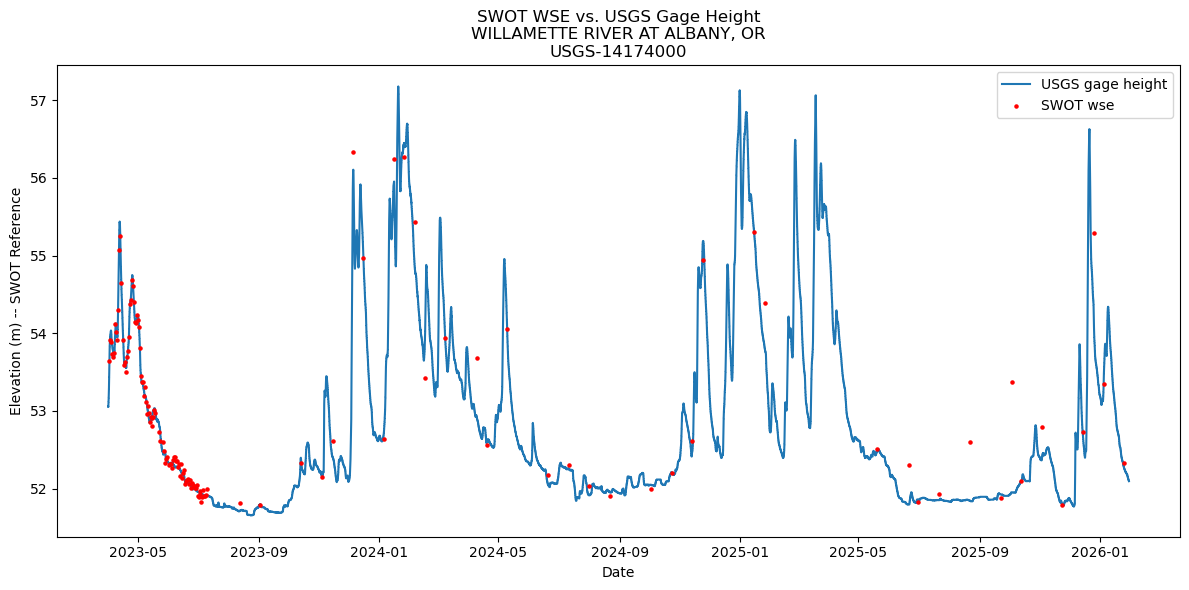

In [186]:
datum_tranform_list = combined['wse']-combined['usgs_height_m']
datum_tranform = datum_tranform_list.median()
# datum_tranform=47.576
fig, ax = plt.subplots(figsize=(12,6))
# plt.plot(combined['nodetime'], combined['usgs_height_m']+datum_tranform, label = "usgs_gage_height")
ax.plot(elevation_data['usgstime'], elevation_data['value']*0.3048+datum_tranform, label = "USGS gage height")
# plt.scatter(combined['nodetime'], combined['wse'], label = "SWOT wse", color='red',s=2)
ax.scatter(combined['nodetime'], combined['wse'], label = "SWOT wse", color='red',s=5, zorder=5)

ax.legend()
ax.set_ylabel("Elevation (m) -- SWOT Reference")
ax.set_xlabel("Date")
# ax.set_xticklabels(rotation=10)
ax.set_title(f"SWOT WSE vs. USGS Gage Height\n{location_info[0].monitoring_location_name[0]}\n{loc_id}")
# ax.set_ylim(45,80)
plt.tight_layout()

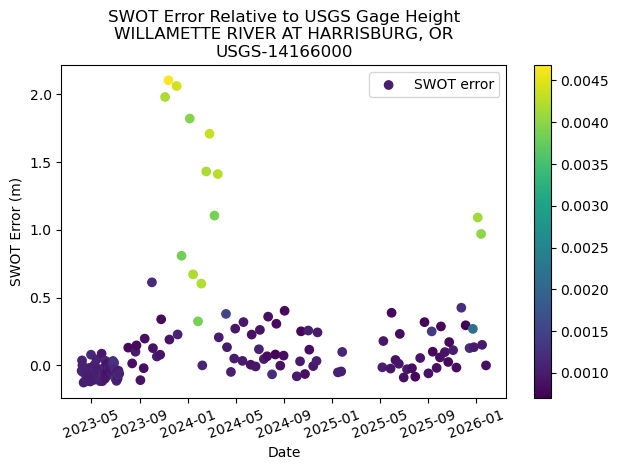

In [258]:
datum_tranform = combined['wse'].min()-combined['usgs_height_m'].min()
usgs_height_datum_transform = combined['usgs_height_m']+datum_tranform
wse = combined['wse']
error = wse-usgs_height_datum_transform
plt.scatter(combined['nodetime'], error, label = "SWOT error", c=combined['dist'])
# plt.(combined['nodetime'], error, label = "SWOT error")

plt.legend()
plt.ylabel("SWOT Error (m)")
plt.xlabel("Date")
plt.xticks(rotation=20)
plt.colorbar()
plt.title(f"SWOT Error Relative to USGS Gage Height\n{location_info[0].monitoring_location_name[0]}\n{loc_id}")
plt.tight_layout()

C:\Users\matth\AppData\Local\Temp\ipykernel_21676\4155715173.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


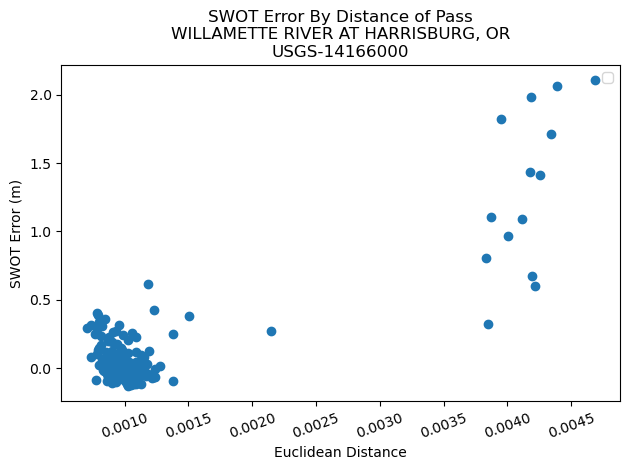

In [259]:
datum_tranform = combined['wse'].min()-combined['usgs_height_m'].min()
usgs_height_datum_transform = combined['usgs_height_m']+datum_tranform
wse = combined['wse']
error = wse-usgs_height_datum_transform
plt.scatter(combined['dist'], error)
# plt.(combined['nodetime'], error, label = "SWOT error")

plt.legend()
plt.ylabel("SWOT Error (m)")
plt.xlabel("Euclidean Distance")
plt.xticks(rotation=20)
# plt.colorbar()
plt.title(f"SWOT Error By Distance of Pass\n{location_info[0].monitoring_location_name[0]}\n{loc_id}")
plt.tight_layout()

In [189]:
combined

,node_id,nodetime,wse,lat,lon,precip_type_labeled,precip_bin_mm_hr,time_series_id,monitoring_location_id,parameter_code,statistic_id,usgstime,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id,usgs_height_m,dist
0,78220000200081,2023-04-02 08:16:17+00:00,53.63833,44.639097,-123.106212,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2023-04-02 08:17:00+00:00,8.84,ft,Approved,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,0.000659
1,78220000200081,2023-04-03 08:06:55+00:00,53.91809,44.639091,-123.105986,Cold Stratiform,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2023-04-03 08:07:00+00:00,9.96,ft,Approved,None,2025-09-02 12:05:01.445830+00:00,ca5aafb4-5bdb-4052-9273-89256cb90ef6,3.035808,0.000855
2,78220000200081,2023-04-04 07:57:33+00:00,53.88590,44.639106,-123.105958,Cold Stratiform,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2023-04-04 07:52:00+00:00,9.99,ft,Approved,None,2025-09-02 12:06:31.949354+00:00,f8b5f23e-7a15-46a7-8c47-5e807a6d070e,3.044952,0.000886
3,78220000200081,2023-04-05 07:48:10+00:00,53.73435,44.639114,-123.106267,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2023-04-05 07:47:00+00:00,9.50,ft,Approved,None,2025-09-02 12:06:31.949354+00:00,ee1222d9-2d1b-4f7a-876c-0155a5cd1799,2.895600,0.000624
4,78220000200081,2023-04-06 07:38:48+00:00,53.69552,44.639087,-123.106341,Warm Stratiform,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2023-04-06 07:37:00+00:00,9.19,ft,Approved,None,2025-09-02 12:06:31.949354+00:00,7f0eb148-6ddc-4768-bc7c-5c141c7eea8b,2.801112,0.000549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,78220000200081,2025-12-14 22:20:52+00:00,52.73309,44.639183,-123.106201,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2025-12-14 22:20:00+00:00,5.68,ft,Provisional,None,2025-12-14 22:27:12.632538+00:00,1e04c957-e05b-4516-9f8a-096288e6b27b,1.731264,0.000719
151,78220000200081,2025-12-25 20:43:46+00:00,55.28452,44.638846,-123.105727,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2025-12-25 20:45:00+00:00,10.75,ft,Provisional,None,2025-12-25 20:51:16.950613+00:00,702c58cb-af97-4f0c-a1c4-e6b67094879a,3.276600,0.001041
152,78220000200081,2026-01-04 19:05:59+00:00,53.34544,44.639128,-123.106318,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2026-01-04 19:05:00+00:00,7.81,ft,Provisional,None,2026-01-04 19:16:14.523867+00:00,dae2bff6-1f74-4dcc-8f7c-ea402198245d,2.380488,0.000594
153,78220000200081,2026-01-15 17:28:50+00:00,60.62840,44.638073,-123.106075,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,00011,2026-01-15 17:30:00+00:00,7.21,ft,Provisional,None,2026-01-15 17:36:14.432482+00:00,19f65dd2-2367-45fa-9f6f-8eac2f2cec4b,2.197608,0.000952


C:\Users\matth\AppData\Local\Temp\ipykernel_21676\1158992589.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


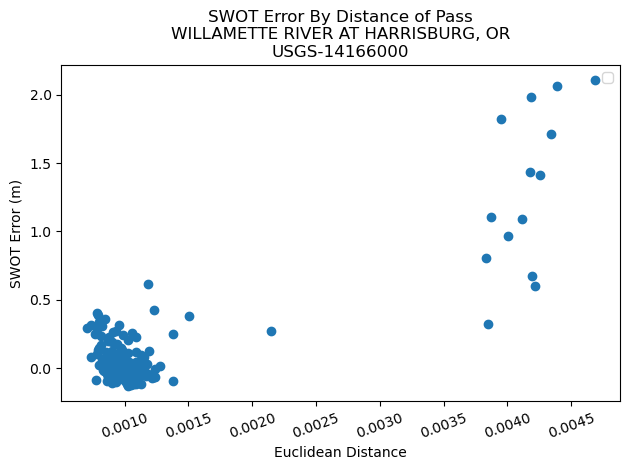

In [260]:
datum_tranform = combined['wse'].min()-combined['usgs_height_m'].min()
usgs_height_datum_transform = combined['usgs_height_m']+datum_tranform
wse = combined['wse']
error = wse-usgs_height_datum_transform
combined['error'] = wse-usgs_height_datum_transform
plt.scatter(combined['dist'], error)
# plt.(combined['nodetime'], error, label = "SWOT error")

plt.legend()
plt.ylabel("SWOT Error (m)")
plt.xlabel("Euclidean Distance")
plt.xticks(rotation=20)
# plt.colorbar()
plt.title(f"SWOT Error By Distance of Pass\n{location_info[0].monitoring_location_name[0]}\n{loc_id}")
plt.tight_layout()

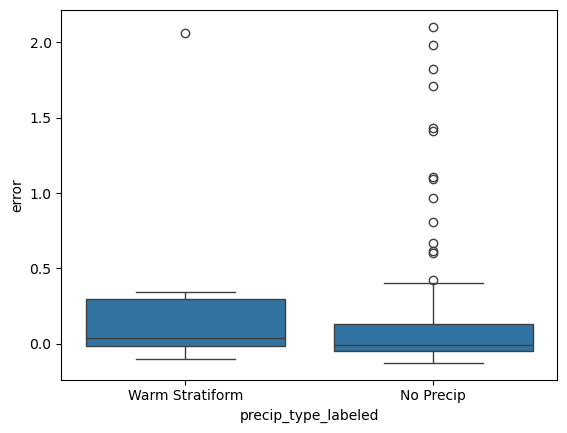

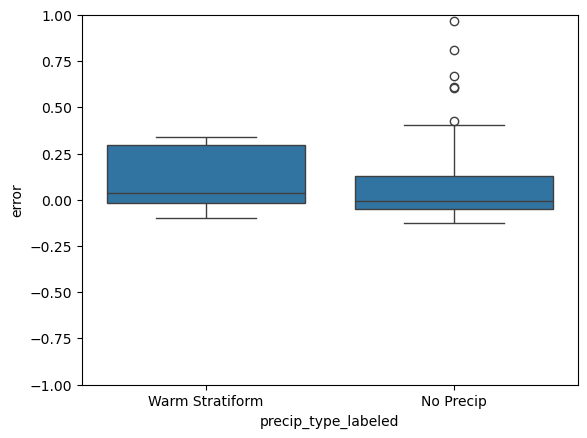

In [261]:
sns.boxplot(
    data=combined,
    x='precip_type_labeled', y='error', log_scale=False
)
# plt.ylim(0,1.2)
# Tilt the labels 45 degrees
# plt.xticks(rotation=20)
plt.show()

sns.boxplot(
    data=combined,
    x='precip_type_labeled', y='error', log_scale=False
)
plt.ylim(-1,1)
# Tilt the labels 45 degrees
# plt.xticks(rotation=20)
plt.show()

C:\Users\matth\AppData\Local\Temp\ipykernel_21676\3129949474.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


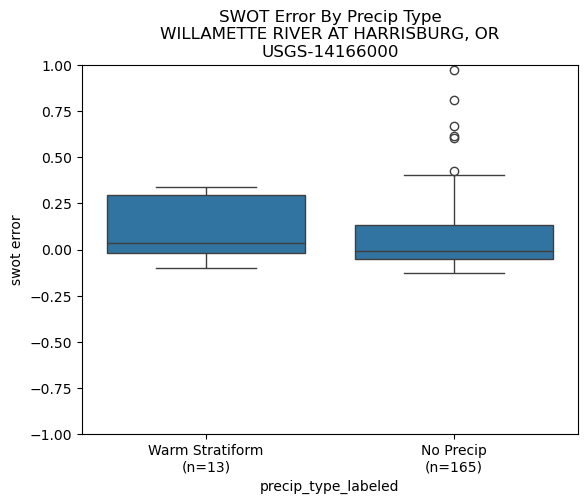

In [262]:
counts = combined.groupby('precip_type_labeled').size()
box_order = combined['precip_type_labeled'].unique()

ax = sns.boxplot(data=combined, x='precip_type_labeled', y='error')
ax.set_xticklabels(
    [f"{cat}\n(n={counts[cat]})" for cat in box_order]
)
plt.title(f"SWOT Error By Precip Type\n{location_info[0].monitoring_location_name[0]}\n{loc_id}")
plt.ylabel("swot error")
plt.ylim(-1,1)
plt.show()

C:\Users\matth\AppData\Local\Temp\ipykernel_21676\1216241368.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


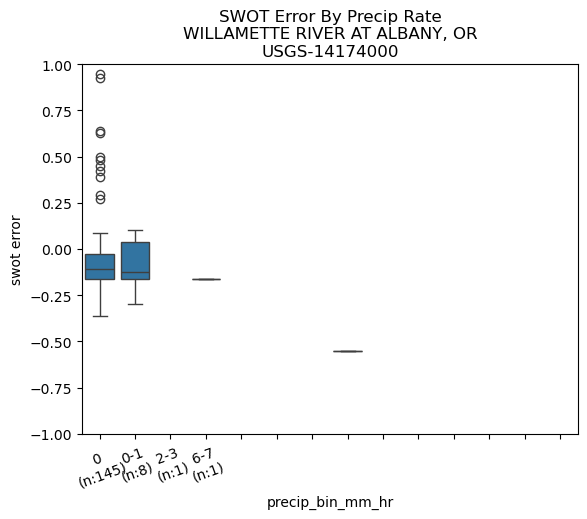

In [242]:
# sns.boxplot(
#     data=combined,
#     x='precip_bin_mm_hr', y='error', log_scale=False
# )
# # plt.ylim(0,1.2)
# # Tilt the labels 45 degrees
# # plt.xticks(rotation=20)
# plt.show()
counts = combined.groupby('precip_bin_mm_hr').size()


ax = sns.boxplot(
    data=combined,
    x='precip_bin_mm_hr', y='error', log_scale=False
)
ax.set_xticklabels(
    [f"{cat}\n(n:{counts[cat]})" for cat in counts.index]
)
plt.title(f"SWOT Error By Precip Rate\n{location_info[0].monitoring_location_name[0]}\n{loc_id}")
plt.ylabel("swot error")
plt.xticks(rotation=20)
plt.ylim(-1,1)
plt.show()

In [238]:
box_order

,node_id,nodetime,wse,lat,lon,precip_type_labeled,time_series_id,monitoring_location_id,parameter_code,statistic_id,usgstime,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id,usgs_height_m,dist,error
precip_bin_mm_hr,,,,,,,,,,,,,,,,,,,,
0,145,145,145,145,145,145,145,145,145,145,145,145,145,145,0,145,145,145,145,145
0-1,8,8,8,8,8,8,8,8,8,8,8,8,8,8,0,8,8,8,8,8
2-3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1
6-7,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1


In [201]:
combined

,node_id,nodetime,wse,lat,lon,precip_type_labeled,precip_bin_mm_hr,time_series_id,monitoring_location_id,parameter_code,...,usgstime,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id,usgs_height_m,dist,error
0,78220000200081,2023-04-02 08:16:17+00:00,53.63833,44.639097,-123.106212,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2023-04-02 08:17:00+00:00,8.84,ft,Approved,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,0.000659,53.757316
1,78220000200081,2023-04-03 08:06:55+00:00,53.91809,44.639091,-123.105986,Cold Stratiform,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2023-04-03 08:07:00+00:00,9.96,ft,Approved,None,2025-09-02 12:05:01.445830+00:00,ca5aafb4-5bdb-4052-9273-89256cb90ef6,3.035808,0.000855,54.098692
2,78220000200081,2023-04-04 07:57:33+00:00,53.88590,44.639106,-123.105958,Cold Stratiform,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2023-04-04 07:52:00+00:00,9.99,ft,Approved,None,2025-09-02 12:06:31.949354+00:00,f8b5f23e-7a15-46a7-8c47-5e807a6d070e,3.044952,0.000886,54.107836
3,78220000200081,2023-04-05 07:48:10+00:00,53.73435,44.639114,-123.106267,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2023-04-05 07:47:00+00:00,9.50,ft,Approved,None,2025-09-02 12:06:31.949354+00:00,ee1222d9-2d1b-4f7a-876c-0155a5cd1799,2.895600,0.000624,53.958484
4,78220000200081,2023-04-06 07:38:48+00:00,53.69552,44.639087,-123.106341,Warm Stratiform,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2023-04-06 07:37:00+00:00,9.19,ft,Approved,None,2025-09-02 12:06:31.949354+00:00,7f0eb148-6ddc-4768-bc7c-5c141c7eea8b,2.801112,0.000549,53.863996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,78220000200081,2025-12-14 22:20:52+00:00,52.73309,44.639183,-123.106201,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2025-12-14 22:20:00+00:00,5.68,ft,Provisional,None,2025-12-14 22:27:12.632538+00:00,1e04c957-e05b-4516-9f8a-096288e6b27b,1.731264,0.000719,52.794148
151,78220000200081,2025-12-25 20:43:46+00:00,55.28452,44.638846,-123.105727,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2025-12-25 20:45:00+00:00,10.75,ft,Provisional,None,2025-12-25 20:51:16.950613+00:00,702c58cb-af97-4f0c-a1c4-e6b67094879a,3.276600,0.001041,54.339484
152,78220000200081,2026-01-04 19:05:59+00:00,53.34544,44.639128,-123.106318,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2026-01-04 19:05:00+00:00,7.81,ft,Provisional,None,2026-01-04 19:16:14.523867+00:00,dae2bff6-1f74-4dcc-8f7c-ea402198245d,2.380488,0.000594,53.443372
153,78220000200081,2026-01-15 17:28:50+00:00,60.62840,44.638073,-123.106075,No Precip,0,20d8f60875fb490f962cb40705f30346,USGS-14174000,00065,...,2026-01-15 17:30:00+00:00,7.21,ft,Provisional,None,2026-01-15 17:36:14.432482+00:00,19f65dd2-2367-45fa-9f6f-8eac2f2cec4b,2.197608,0.000952,53.260492
